In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors

In [2]:
exposure = pd.read_csv("data/2025-10-30_exposure.csv")
responses = pd.read_csv("data/2026-01-27_responses.csv")
feedback = pd.read_csv("data/2025-10-30_feedback.csv")

users = pd.read_csv("data/2025-10-30_users.csv")
user_thetas = pd.read_csv("data/2025-11-14_user_thetas.csv")

item_params = pd.read_csv("data/2025-11-04_item_parameters_Rasch.csv")
item_statistics = pd.read_csv("data/2025-11-04_item_statistics.csv")

questions = pd.read_csv("data/2025-10-30_questions.csv")
question_texts = pd.read_excel("data/question_texts.xlsx")


print("exposure:", exposure.shape)
print("question_texts:", question_texts.shape)
print("responses:", responses.shape)
print("feedback:", feedback.shape)
print("users:", users.shape)
print("user_thetas:", user_thetas.shape)
print("item_params:", item_params.shape)
print("item_statistics:", item_statistics.shape)
print("questions:", questions.shape)


exposure: (159, 5)
question_texts: (159, 3)
responses: (97382, 15)
feedback: (26945, 8)
users: (6573, 10)
user_thetas: (2356, 3)
item_params: (879, 9)
item_statistics: (879, 9)
questions: (1164, 7)


In [3]:
exposure.head()

,sanity_text_id,n,serialNumber,title,pct
0,91b545bd-9dad-42d8-aa78-a650f31ed6e8,2702,NaN,Vil du hjelpe oss med forskningen vår?,0.137611
1,3c792d1d-4254-4cd6-9add-f54548fcb0b4,165,HT_128_PremierLeague,Premier League,0.008403
2,193d0c96-d9ff-4984-9964-4304123f20a2,160,HT_127_Eliteserien,Eliteserien i fotball,0.008149
3,ffffece4-14da-4ed0-819a-a7039a0101d1,147,HT_52_Minecraft,Minecraft,0.007487
4,c83708d2-4a21-43ad-bea4-a193faac8d14,147,HT_139_Haier,Haier,0.007487


In [4]:
responses.head()

,answer_id,student_answer,student_id,sanity_text_id,sanity_question_key,sanity_option_key,scale,serialNumber,type,correct_answer,student_answer_bool,correct,item_id,question_id,text_id
0,125,True,6643,91b545bd-9dad-42d8-aa78-a650f31ed6e8,ad852edab65d,467726062e54,ability,NaN,multiChoice,True,True,True,1,1,1
1,126,True,6643,91b545bd-9dad-42d8-aa78-a650f31ed6e8,7ee58bf2a444,839fa70d1a2d,ability,NaN,multiChoice,True,True,True,2,2,1
2,127,True,6632,91b545bd-9dad-42d8-aa78-a650f31ed6e8,ad852edab65d,467726062e54,ability,NaN,multiChoice,True,True,True,1,1,1
3,128,True,6632,91b545bd-9dad-42d8-aa78-a650f31ed6e8,7ee58bf2a444,839fa70d1a2d,ability,NaN,multiChoice,True,True,True,2,2,1
4,129,True,6633,91b545bd-9dad-42d8-aa78-a650f31ed6e8,ad852edab65d,467726062e54,ability,NaN,multiChoice,True,True,True,1,1,1


In [5]:
questions.head()

,sanity_text_id,sanity_question_key,sanity_option_key,scale,serialNumber,type,correct_answer
0,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,ba19153d3561,bd938febbf0b,ability,HT_105_Ørner,multiChoice,True
1,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,ea9c7a756e38,6865903547ca,ability,HT_105_Ørner,multiChoice,True
2,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,ad690b948e2a,64596db46cd7,ability,HT_105_Ørner,multiChoice,True
3,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,c3fbfdd179ac,NaN,preference,HT_105_Ørner,scaleFeedback,NaN
4,0202b907-4516-4beb-8e07-759e473b5ea2,6fa81bbdb643,957bfc69375d,ability,HT_43_Astronaut,multiChoice,True


In [6]:
questions.describe(include='all')

,sanity_text_id,sanity_question_key,sanity_option_key,scale,serialNumber,type,correct_answer
count,1164,1164,891,1164,1162,1164,891
unique,159,766,888,2,158,5,2
top,563d2e7a-69af-4adc-ba62-bb966de71872,ee21417e5bd7,f83db5312cbd,ability,HT_72_Danmark,multiChoice,True
freq,19,8,2,1006,19,367,673


In [7]:
exposure.describe(include='all')

,sanity_text_id,n,serialNumber,title,pct
count,159,159.000000,158,159,159.000000
unique,159,NaN,158,159,NaN
top,91b545bd-9dad-42d8-aa78-a650f31ed6e8,NaN,HT_128_PremierLeague,Vil du hjelpe oss med forskningen vår?,NaN
freq,1,NaN,1,1,NaN
mean,NaN,123.490566,NaN,NaN,0.006289
std,NaN,206.703079,NaN,NaN,0.010527
min,NaN,63.000000,NaN,NaN,0.003209
25%,NaN,94.000000,NaN,NaN,0.004787
50%,NaN,108.000000,NaN,NaN,0.005500
75%,NaN,119.000000,NaN,NaN,0.006061


In [8]:
question_texts.describe(include='all')


,serialNumber,title,body
count,158,159,159
unique,158,159,159
top,HT_105_√òrner,√òrner,## √òrner\n\n![√òrn med fisk i kl√∏rne. Foto.]...
freq,1,1,1


In [9]:
responses.describe(include='all')


,answer_id,student_answer,student_id,sanity_text_id,sanity_question_key,sanity_option_key,scale,serialNumber,type,correct_answer,student_answer_bool,correct,item_id,question_id,text_id
count,97382.000000,78746,97382.000000,97382,97382,97382,97382,92325,97382,97372,97382,97372,97382.000000,97382.000000,97382.000000
unique,NaN,2,NaN,154,509,1817,1,153,3,2,2,2,NaN,NaN,NaN
top,NaN,True,NaN,91b545bd-9dad-42d8-aa78-a650f31ed6e8,7ee58bf2a444,467726062e54,ability,HT_15_Dukker,multiChoice,True,True,True,NaN,NaN,NaN
freq,NaN,64521,NaN,5057,2538,2484,97382,1631,46438,57931,64521,68113,NaN,NaN,NaN
mean,184784.976885,NaN,3450.857489,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,699.806361,299.033179,78.547380
std,50119.540276,NaN,2029.911685,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,501.768395,187.621608,48.308446
min,125.000000,NaN,19.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000
25%,162104.250000,NaN,1876.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,273.000000,145.000000,37.000000
50%,191713.500000,NaN,3370.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,652.000000,297.000000,81.000000
75%,221524.500000,NaN,5275.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1034.000000,462.000000,122.000000


In [10]:
users.describe(include='all')


,user_id,username,role_id,role,classroom_id,classroom,school_id,school,parental_consent,student_consent
count,6573.000000,6573,6573.0,6573,6573.000000,6573,6573.0,6573,6573,2599
unique,NaN,6573,NaN,1,NaN,138,NaN,1,2,2
top,NaN,SunnSjef,NaN,Student,NaN,Skole 4,NaN,Pilot 1,True,True
freq,NaN,1,NaN,6573,NaN,180,NaN,6573,6559,2422
mean,3378.857599,NaN,3.0,NaN,80.494903,NaN,5.0,NaN,NaN,NaN
std,1941.376868,NaN,0.0,NaN,46.377990,NaN,0.0,NaN,NaN,NaN
min,18.000000,NaN,3.0,NaN,8.000000,NaN,5.0,NaN,NaN,NaN
25%,1697.000000,NaN,3.0,NaN,39.000000,NaN,5.0,NaN,NaN,NaN
50%,3380.000000,NaN,3.0,NaN,80.000000,NaN,5.0,NaN,NaN,NaN
75%,5060.000000,NaN,3.0,NaN,121.000000,NaN,5.0,NaN,NaN,NaN


In [11]:
user_thetas.describe(include='all')


,user_id,Rasch,3PL
count,2356.000000,2356.000000,2356.000000
mean,3472.773769,-0.000053,-0.061752
std,2024.815906,0.705808,0.911355
min,19.000000,-2.975077,-4.558115
25%,1893.750000,-0.418357,-0.564901
50%,3410.500000,0.056280,-0.005359
75%,5267.000000,0.479570,0.552612
max,6743.000000,1.860956,2.368929


In [12]:
item_params.describe(include='all')


,item_id,a,b,g,u,sanity_text_id,sanity_question_key,sanity_option_key,serialNumber
count,879.00000,879.0,879.000000,879.0,879.0,879,879,879,879
unique,NaN,NaN,NaN,NaN,NaN,150,499,876,150
top,NaN,NaN,NaN,NaN,NaN,563d2e7a-69af-4adc-ba62-bb966de71872,ee21417e5bd7,f83db5312cbd,HT_72_Danmark
freq,NaN,NaN,NaN,NaN,NaN,18,8,2,18
mean,440.00000,1.0,-1.895709,0.0,1.0,NaN,NaN,NaN,NaN
std,253.88974,0.0,1.166142,0.0,0.0,NaN,NaN,NaN,NaN
min,1.00000,1.0,-5.183914,0.0,1.0,NaN,NaN,NaN,NaN
25%,220.50000,1.0,-2.714677,0.0,1.0,NaN,NaN,NaN,NaN
50%,440.00000,1.0,-1.892547,0.0,1.0,NaN,NaN,NaN,NaN
75%,659.50000,1.0,-1.130383,0.0,1.0,NaN,NaN,NaN,NaN


In [13]:
item_params_2 = item_params.copy()
item_params_2["item_id"] = item_params_2["item_id"].astype(str)

In [14]:
item_params_2.describe(include='all')

,item_id,a,b,g,u,sanity_text_id,sanity_question_key,sanity_option_key,serialNumber
count,879,879.0,879.000000,879.0,879.0,879,879,879,879
unique,879,NaN,NaN,NaN,NaN,150,499,876,150
top,225,NaN,NaN,NaN,NaN,563d2e7a-69af-4adc-ba62-bb966de71872,ee21417e5bd7,f83db5312cbd,HT_72_Danmark
freq,1,NaN,NaN,NaN,NaN,18,8,2,18
mean,NaN,1.0,-1.895709,0.0,1.0,NaN,NaN,NaN,NaN
std,NaN,0.0,1.166142,0.0,0.0,NaN,NaN,NaN,NaN
min,NaN,1.0,-5.183914,0.0,1.0,NaN,NaN,NaN,NaN
25%,NaN,1.0,-2.714677,0.0,1.0,NaN,NaN,NaN,NaN
50%,NaN,1.0,-1.892547,0.0,1.0,NaN,NaN,NaN,NaN
75%,NaN,1.0,-1.130383,0.0,1.0,NaN,NaN,NaN,NaN


In [15]:
item_statistics.describe(include='all')


,item_id,n_responses,prop_correct,item_test_correlation,sanity_text_id,sanity_question_key,sanity_option_key,serialNumber,avg_preference
count,879.000000,879.000000,879.000000,879.000000,879,879,879,879,879.000000
unique,NaN,NaN,NaN,NaN,153,498,876,153,NaN
top,NaN,NaN,NaN,NaN,563d2e7a-69af-4adc-ba62-bb966de71872,ee21417e5bd7,f83db5312cbd,HT_72_Danmark,NaN
freq,NaN,NaN,NaN,NaN,18,8,2,18,NaN
mean,446.414107,83.315131,0.789122,0.287132,NaN,NaN,NaN,NaN,3.239964
std,256.412314,22.883077,0.158692,0.129781,NaN,NaN,NaN,NaN,0.374201
min,1.000000,13.000000,0.105263,-0.378340,NaN,NaN,NaN,NaN,2.369863
25%,225.500000,69.500000,0.706782,0.207907,NaN,NaN,NaN,NaN,2.966292
50%,447.000000,85.000000,0.827586,0.294629,NaN,NaN,NaN,NaN,3.205607
75%,668.500000,99.000000,0.912023,0.374056,NaN,NaN,NaN,NaN,3.530612


In [16]:
item_statistics_2 = item_statistics.copy()
item_statistics_2["item_id"] = item_params_2["item_id"].astype(str)

In [17]:
item_statistics_2.describe(include='all')

,item_id,n_responses,prop_correct,item_test_correlation,sanity_text_id,sanity_question_key,sanity_option_key,serialNumber,avg_preference
count,879,879.000000,879.000000,879.000000,879,879,879,879,879.000000
unique,879,NaN,NaN,NaN,153,498,876,153,NaN
top,225,NaN,NaN,NaN,563d2e7a-69af-4adc-ba62-bb966de71872,ee21417e5bd7,f83db5312cbd,HT_72_Danmark,NaN
freq,1,NaN,NaN,NaN,18,8,2,18,NaN
mean,NaN,83.315131,0.789122,0.287132,NaN,NaN,NaN,NaN,3.239964
std,NaN,22.883077,0.158692,0.129781,NaN,NaN,NaN,NaN,0.374201
min,NaN,13.000000,0.105263,-0.378340,NaN,NaN,NaN,NaN,2.369863
25%,NaN,69.500000,0.706782,0.207907,NaN,NaN,NaN,NaN,2.966292
50%,NaN,85.000000,0.827586,0.294629,NaN,NaN,NaN,NaN,3.205607
75%,NaN,99.000000,0.912023,0.374056,NaN,NaN,NaN,NaN,3.530612


In [18]:
feedback.describe(include='all')

,feedback_id,sanity_text_id,sanity_question_key,student_answer,student_id,scale,serialNumber,type
count,26945.000000,26945,26945,26286.000000,26945.000000,16566,16566,16566
unique,NaN,159,156,NaN,NaN,1,158,1
top,NaN,56c0e9bf-a4f1-4f6f-8153-6836ca2c81d6,b2147cfaeb93,NaN,NaN,preference,HT_08_Mobbing,scaleFeedback
freq,NaN,3347,546,NaN,NaN,16566,241,16566
mean,14212.403229,NaN,NaN,3.129042,3808.315123,NaN,NaN,NaN
std,8371.822835,NaN,NaN,1.315428,1950.015636,NaN,NaN,NaN
min,38.000000,NaN,NaN,1.000000,19.000000,NaN,NaN,NaN
25%,6828.000000,NaN,NaN,2.000000,2251.000000,NaN,NaN,NaN
50%,14129.000000,NaN,NaN,3.000000,4607.000000,NaN,NaN,NaN
75%,21461.000000,NaN,NaN,4.000000,5109.000000,NaN,NaN,NaN


In [19]:
user_thetas.head()

,user_id,Rasch,3PL
0,6208,0.554910,0.988615
1,6203,0.807340,1.179093
2,4929,-0.065195,0.142492
3,3138,0.697116,1.010295
4,3122,-0.019453,-0.016740


In [20]:
item_params.head()

,item_id,a,b,g,u,sanity_text_id,sanity_question_key,sanity_option_key,serialNumber
0,225,1,-2.158127,0,1,2edc7545-6e2c-4444-b095-a33eef9d89b5,25d071a78d0f,235d73d0ff8a,HT_01_Promp
1,226,1,-2.853890,0,1,2edc7545-6e2c-4444-b095-a33eef9d89b5,25d071a78d0f,77078ea940e0,HT_01_Promp
2,227,1,-3.415364,0,1,2edc7545-6e2c-4444-b095-a33eef9d89b5,25d071a78d0f,c602fd06a4ad,HT_01_Promp
3,228,1,-2.516826,0,1,2edc7545-6e2c-4444-b095-a33eef9d89b5,78c8875d5160,f9e2db73e448,HT_01_Promp
4,229,1,-2.236764,0,1,2edc7545-6e2c-4444-b095-a33eef9d89b5,7cf198887588,468728af46ce,HT_01_Promp


In [21]:
item_params.describe()

,item_id,a,b,g,u
count,879.00000,879.0,879.000000,879.0,879.0
mean,440.00000,1.0,-1.895709,0.0,1.0
std,253.88974,0.0,1.166142,0.0,0.0
min,1.00000,1.0,-5.183914,0.0,1.0
25%,220.50000,1.0,-2.714677,0.0,1.0
50%,440.00000,1.0,-1.892547,0.0,1.0
75%,659.50000,1.0,-1.130383,0.0,1.0
max,879.00000,1.0,2.295808,0.0,1.0


In [22]:
text_difficulty = item_params.groupby("sanity_text_id")["b"].mean().reset_index()
text_difficulty.rename(columns={"b": "text_difficulty"}, inplace=True)

In [23]:
text_difficulty.head()

,sanity_text_id,text_difficulty
0,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,-2.455900
1,0202b907-4516-4beb-8e07-759e473b5ea2,-1.796683
2,02df17fa-3bfa-4f87-8cd5-d523c12c9a1f,-1.595484
3,035af603-c895-4f40-a3e8-4b05a07a09bd,-1.738840
4,05c18c0e-b6b5-40b8-9009-130b044693c6,-1.201098


In [24]:
text_difficulty.describe(include='all')

,sanity_text_id,text_difficulty
count,150,150.000000
unique,150,NaN
top,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,NaN
freq,1,NaN
mean,NaN,-1.920610
std,NaN,0.677233
min,NaN,-3.608110
25%,NaN,-2.360198
50%,NaN,-1.877934
75%,NaN,-1.496732


In [25]:
text_difficulty = text_difficulty.merge(
    exposure[["sanity_text_id", "title", "serialNumber"]],
    on="sanity_text_id",
    how="left"
)

In [26]:
text_difficulty.head()

,sanity_text_id,text_difficulty,title,serialNumber
0,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,-2.455900,Ørner,HT_105_Ørner
1,0202b907-4516-4beb-8e07-759e473b5ea2,-1.796683,Astronaut,HT_43_Astronaut
2,02df17fa-3bfa-4f87-8cd5-d523c12c9a1f,-1.595484,Snork,HT_04_Snork
3,035af603-c895-4f40-a3e8-4b05a07a09bd,-1.738840,Miniatyrer - gjennom nåløyet,HT_125_Miniatyrer-William
4,05c18c0e-b6b5-40b8-9009-130b044693c6,-1.201098,NRK,HT_135_NRK


In [27]:
text_difficulty.describe(include='all')

,sanity_text_id,text_difficulty,title,serialNumber
count,150,150.000000,150,150
unique,150,NaN,150,150
top,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,NaN,Ørner,HT_105_Ørner
freq,1,NaN,1,1
mean,NaN,-1.920610,NaN,NaN
std,NaN,0.677233,NaN,NaN
min,NaN,-3.608110,NaN,NaN
25%,NaN,-2.360198,NaN,NaN
50%,NaN,-1.877934,NaN,NaN
75%,NaN,-1.496732,NaN,NaN


In [28]:
user_theta = user_thetas[["user_id", "Rasch"]].rename(columns={"Rasch": "theta"})

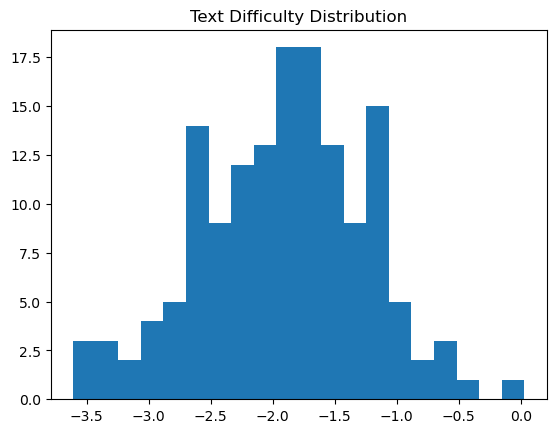

In [29]:
import matplotlib.pyplot as plt

plt.hist(text_difficulty["text_difficulty"], bins=20)
plt.title("Text Difficulty Distribution")
plt.show()

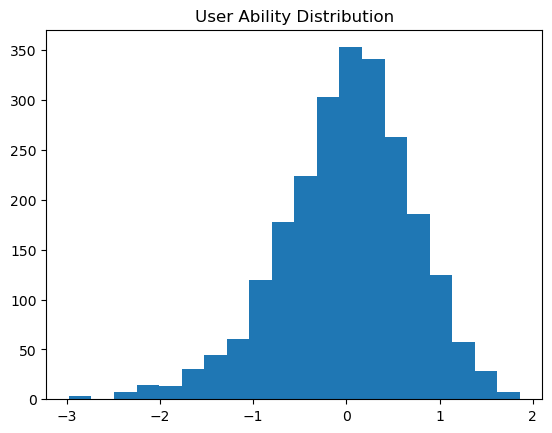

In [30]:
plt.hist(user_theta["theta"], bins=20)
plt.title("User Ability Distribution")
plt.show()

In [31]:
user_seen = responses.groupby("student_id")["sanity_text_id"].unique()

In [32]:
def recommend_texts(user_id, k=5):

    theta = user_theta.loc[user_theta.user_id == user_id, "theta"].values[0]

    seen = user_seen.get(user_id, [])

    candidates = text_difficulty[~text_difficulty["sanity_text_id"].isin(seen)].copy()

    candidates["distance"] = abs(candidates["text_difficulty"] - theta)

    return candidates.sort_values("distance").head(k)

In [33]:
recommend_texts(6208, k=5)

,sanity_text_id,text_difficulty,title,serialNumber,distance
102,b756c735-64ce-4b67-933f-df89305b3e98,0.028054,Boksen går,HT_83_BoksenGår,0.526856
103,ba75b0bf-ba64-46c4-bbde-3e160a7ff2b6,-0.539528,Forskeporske - skal det være litt øremidd?,HT_117_Forskeporske2,1.094438
17,146f4451-5399-4d06-92ae-b4e638f22fc6,-0.557586,Skihopping,HT_130_Skihopping,1.112497
130,e90f7412-d351-451d-b439-00496e632439,-0.596926,Hvordan kan man kommunisere gjennom tegn?,HT_24_Tegn,1.151836
86,9cec37e6-8377-4bb7-b7a8-c342fbc40cdd,-0.801288,Sjokolademaskinen,HT_56_Sjokolademaskinen,1.356199


In [34]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

X = text_difficulty[["text_difficulty"]].values

knn = NearestNeighbors(n_neighbors=20)

knn.fit(X)

,n_neighbors,20
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,None


In [35]:
def recommend_texts_knn(user_id, k=5):

    theta = user_theta.loc[user_theta.user_id == user_id, "theta"].values[0]

    seen = user_seen.get(user_id, [])

    distances, indices = knn.kneighbors([[theta]])

    recs = text_difficulty.iloc[indices[0]].copy()

    recs = recs[~recs["sanity_text_id"].isin(seen)]

    return recs.head(k)

In [36]:
recommend_texts_knn(6208, k=5)

,sanity_text_id,text_difficulty,title,serialNumber
102,b756c735-64ce-4b67-933f-df89305b3e98,0.028054,Boksen går,HT_83_BoksenGår
103,ba75b0bf-ba64-46c4-bbde-3e160a7ff2b6,-0.539528,Forskeporske - skal det være litt øremidd?,HT_117_Forskeporske2
17,146f4451-5399-4d06-92ae-b4e638f22fc6,-0.557586,Skihopping,HT_130_Skihopping
130,e90f7412-d351-451d-b439-00496e632439,-0.596926,Hvordan kan man kommunisere gjennom tegn?,HT_24_Tegn
86,9cec37e6-8377-4bb7-b7a8-c342fbc40cdd,-0.801288,Sjokolademaskinen,HT_56_Sjokolademaskinen


In [37]:
recommend_texts(6208, k=5)

,sanity_text_id,text_difficulty,title,serialNumber,distance
102,b756c735-64ce-4b67-933f-df89305b3e98,0.028054,Boksen går,HT_83_BoksenGår,0.526856
103,ba75b0bf-ba64-46c4-bbde-3e160a7ff2b6,-0.539528,Forskeporske - skal det være litt øremidd?,HT_117_Forskeporske2,1.094438
17,146f4451-5399-4d06-92ae-b4e638f22fc6,-0.557586,Skihopping,HT_130_Skihopping,1.112497
130,e90f7412-d351-451d-b439-00496e632439,-0.596926,Hvordan kan man kommunisere gjennom tegn?,HT_24_Tegn,1.151836
86,9cec37e6-8377-4bb7-b7a8-c342fbc40cdd,-0.801288,Sjokolademaskinen,HT_56_Sjokolademaskinen,1.356199


In [38]:
texts_per_student = (
    responses.groupby("student_id")["sanity_text_id"]
    .nunique()
    .reset_index(name="n_texts_attempted")
)

texts_per_student.head()

,student_id,n_texts_attempted
0,19,10
1,22,3
2,24,5
3,25,11
4,26,6


In [39]:
texts_per_student_all = (
    users[["user_id"]]
    .merge(
        responses.groupby("student_id")["sanity_text_id"]
        .nunique()
        .reset_index(name="n_texts_attempted"),
        left_on="user_id",
        right_on="student_id",
        how="left"
    )
    .drop(columns="student_id")
    .fillna({"n_texts_attempted": 0})
)

texts_per_student_all["n_texts_attempted"] = texts_per_student_all["n_texts_attempted"].astype(int)

In [40]:
students_with_0_texts = texts_per_student_all[texts_per_student_all["n_texts_attempted"] == 0]

In [41]:
len(students_with_0_texts)

4152

In [42]:
students_with_atleast_1_texts = texts_per_student_all[texts_per_student_all["n_texts_attempted"] >= 1]

In [43]:
len(students_with_atleast_1_texts)

2421

In [46]:
student_item_counts = (
    responses.groupby(
        ["student_id", "sanity_text_id", "sanity_question_key", "sanity_option_key"]
    )
    .size()
    .reset_index(name="n_rows")
)

duplicate_item_attempts = student_item_counts[student_item_counts["n_rows"] > 1]
duplicate_item_attempts.head()

,student_id,sanity_text_id,sanity_question_key,sanity_option_key,n_rows
0,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,5c54ebaafe0a,2add953b7ef0,2
1,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,5c54ebaafe0a,417ccc797cd5,2
2,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,5c54ebaafe0a,9257b0cc59d6,2
3,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,5c54ebaafe0a,e049c25c5338,2
4,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,7568b5b522b4,b2ae0c027294,2


In [50]:
duplicate_item_attempts = (
    responses.groupby(
        ["student_id", "sanity_text_id", "sanity_question_key", "sanity_option_key"]
    )
    .size()
    .reset_index(name="n_rows")
)

duplicate_item_attempts = duplicate_item_attempts[
    duplicate_item_attempts["n_rows"] > 1
]

duplicate_item_attempts.head()

,student_id,sanity_text_id,sanity_question_key,sanity_option_key,n_rows
0,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,5c54ebaafe0a,2add953b7ef0,2
1,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,5c54ebaafe0a,417ccc797cd5,2
2,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,5c54ebaafe0a,9257b0cc59d6,2
3,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,5c54ebaafe0a,e049c25c5338,2
4,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,7568b5b522b4,b2ae0c027294,2


In [47]:
def show_text_questions_options(df, text_id=None, serial=None):
    if text_id is not None:
        subset = df[df["sanity_text_id"] == text_id].copy()
    elif serial is not None:
        subset = df[df["serialNumber"] == serial].copy()
    else:
        raise ValueError("Provide either text_id or serial")

    if subset.empty:
        print("No matching text found.")
        return

    print("Title:", subset["title"].iloc[0])
    print("Serial:", subset["serialNumber"].iloc[0])
    print("\nText:\n")
    print(subset["text"].iloc[0])

    for qid, qgroup in subset.groupby("sanity_question_key"):
        print("\n" + "=" * 70)
        print("Question:", qgroup["question"].iloc[0])
        print("Type:", qgroup["type"].iloc[0])

        for _, row in qgroup.iterrows():
            print(f"  - {row['option']}  (Correct: {row['is_correct']})")

In [48]:
joined_question_texts = pd.read_csv("data/joined_question_texts.csv")

In [49]:
show_text_questions_options(joined_question_texts, serial="HT_105_Ørner")

Title: Ørner
Serial: HT_105_Ørner

Text:

## Ørner

![Ørn med fisk i klørne. Foto.]()

### Ørner

Ørner er et felles navn på ulike arter av rovfugler. Ørner er som regel store, kraftige fugler med krokete nebb og skarpe klør på føttene.
I Norge hekker havørn, kongeørn og fiskeørn.


### Levevis


Ørner er rovfugler som spiser andre dyr. Noen av de største ørnene fanger og spiser mellomstore pattedyr og fugler. Andre ørner spiser mest fisk og reptiler. De minste ørnene spiser insekter og andre småkryp. De fleste ørnene spiser også åtsel.
Ørner er øverst i næringskjeden og viktig i mange økosystemer.


### Ørn i kulturen


Mennesker har alltid hatt et spesielt forhold til ørner:
Man har brukt fjær og klør fra ørn som pynt, symboler og gaver til gudene. I religionen hos noen urfolk i Nord-Amerika har ørnen vært den helligste av alle fugler. Det var særlig fjær fra unge kongeørner som ble brukt til å pynte hodet med.
Ifølge norrøn mytologi sitter ørnen Vidofnir i toppen av verdenstreet Ygg

In [52]:
questions_per_text = (
    questions.groupby("sanity_text_id")["sanity_question_key"]
    .nunique()
    .reset_index(name="n_questions_in_text")
)

questions_per_text.head()

,sanity_text_id,n_questions_in_text
0,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,4
1,0202b907-4516-4beb-8e07-759e473b5ea2,4
2,02df17fa-3bfa-4f87-8cd5-d523c12c9a1f,5
3,035af603-c895-4f40-a3e8-4b05a07a09bd,6
4,05c18c0e-b6b5-40b8-9009-130b044693c6,10


In [53]:
student_text_question_counts = (
    responses.groupby(["student_id", "sanity_text_id", "sanity_question_key"])
    .size()
    .reset_index(name="n_rows")
)

student_text_question_counts.head()

,student_id,sanity_text_id,sanity_question_key,n_rows
0,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,5c54ebaafe0a,8
1,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,7568b5b522b4,6
2,19,5444acd1-af3e-4741-96d9-069cd4284db5,0a994b495b2b,3
3,19,5444acd1-af3e-4741-96d9-069cd4284db5,ae8c0eaaf2b3,1
4,19,5444acd1-af3e-4741-96d9-069cd4284db5,b32dc0ccd4bf,1


In [55]:
repeated_questions_per_text = (
    student_text_question_counts.assign(repeated=lambda d: d["n_rows"] > 1)
    .groupby(["student_id", "sanity_text_id"])["repeated"]
    .sum()
    .reset_index(name="n_repeated_questions")
)

repeated_questions_per_text.head()

,student_id,sanity_text_id,n_repeated_questions
0,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,2
1,19,5444acd1-af3e-4741-96d9-069cd4284db5,1
2,19,5b1d7ea2-04c0-472c-848d-ca34d672ef6f,4
3,19,8617745a-2700-4c0a-9854-1cd0e90a5192,0
4,19,91b545bd-9dad-42d8-aa78-a650f31ed6e8,0


In [56]:
text_reattempt_check = repeated_questions_per_text.merge(
    questions_per_text,
    on="sanity_text_id",
    how="left"
)

text_reattempt_check["all_questions_repeated"] = (
    text_reattempt_check["n_repeated_questions"] == text_reattempt_check["n_questions_in_text"]
)

text_reattempt_check["repeat_fraction"] = (
    text_reattempt_check["n_repeated_questions"] / text_reattempt_check["n_questions_in_text"]
)

In [57]:
text_reattempt_check[text_reattempt_check["all_questions_repeated"]]

,student_id,sanity_text_id,n_repeated_questions,n_questions_in_text,all_questions_repeated,repeat_fraction
554,208,91b545bd-9dad-42d8-aa78-a650f31ed6e8,2,2,True,1.0
1384,432,91b545bd-9dad-42d8-aa78-a650f31ed6e8,2,2,True,1.0
1845,616,91b545bd-9dad-42d8-aa78-a650f31ed6e8,2,2,True,1.0
4176,1857,91b545bd-9dad-42d8-aa78-a650f31ed6e8,2,2,True,1.0
4348,1893,91b545bd-9dad-42d8-aa78-a650f31ed6e8,2,2,True,1.0
4357,1894,91b545bd-9dad-42d8-aa78-a650f31ed6e8,2,2,True,1.0
4371,1896,91b545bd-9dad-42d8-aa78-a650f31ed6e8,2,2,True,1.0
4436,1908,91b545bd-9dad-42d8-aa78-a650f31ed6e8,2,2,True,1.0
4540,1926,91b545bd-9dad-42d8-aa78-a650f31ed6e8,2,2,True,1.0
4551,2010,91b545bd-9dad-42d8-aa78-a650f31ed6e8,2,2,True,1.0


In [58]:
likely_reattempts = text_reattempt_check[text_reattempt_check["repeat_fraction"] >= 0.8]

In [59]:
student_id = 6208

student_questions = (
    responses.loc[responses["student_id"] == student_id, "sanity_question_key"]
    .dropna()
    .unique()
)

student_questions

array(['ad852edab65d', '7ee58bf2a444', '1f84a8ea3f7f',
       'da74bcad3c0b77e93987b368be86a560',
       '81bf53a33cfaa3a8ffde02b5521ba0a5', '1651b9797ea1', '20e5b0172417',
       '4c41057a4b79', '83e99437f5c3', '740a32a66d7a', 'b67ab5251039',
       '642ecc5683b7', '2eb8ab503d43', '0891dd4fc639', '24430f499320',
       '89f9922a8cdf', '4d4836cc569a', '538b7ced525d', 'de74587600f7',
       '242d95522bb4', 'b8f088dc93a8', 'ba19153d3561', 'ea9c7a756e38',
       'ad690b948e2a', '7ad7cfa7e759', '74b7d160867c', '3ddcd0a41be3',
       'adec2cef19cb', '835188a60b79', '82b384cb8c46', '5114f2c08c55',
       '93d59fe31d85', '873aff046e0f', '4b97b58d3dbd', 'e7296213ea51',
       '046476a58f16', 'a62960308ad0'], dtype=object)

In [60]:
student_q = (
    responses.loc[responses["student_id"] == student_id,
                  ["sanity_text_id", "sanity_question_key", "serialNumber", "type", "scale"]]
    .drop_duplicates()
    .sort_values(["sanity_text_id", "sanity_question_key"])
)

In [61]:
student_q.head(20)

,sanity_text_id,sanity_question_key,serialNumber,type,scale
2637,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,ad690b948e2a,HT_105_Ørner,multiChoice,ability
2635,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,ba19153d3561,HT_105_Ørner,multiChoice,ability
2636,01ff8ad2-ef5b-4cf2-8f1d-b44663790fa4,ea9c7a756e38,HT_105_Ørner,multiChoice,ability
2674,0af832ca-a33b-4606-96ce-1904d99101d3,3ddcd0a41be3,HT_143_Unionsoppløsningen,multiChoice,ability
2673,0af832ca-a33b-4606-96ce-1904d99101d3,74b7d160867c,HT_143_Unionsoppløsningen,multiChoice,ability
2670,0af832ca-a33b-4606-96ce-1904d99101d3,7ad7cfa7e759,HT_143_Unionsoppløsningen,trueOrFalse,ability
2031,193d0c96-d9ff-4984-9964-4304123f20a2,1651b9797ea1,HT_127_Eliteserien,multiChoice,ability
2162,1de161e8-b8f0-47ef-8a0c-17de6d7bc9b9,0891dd4fc639,HT_80_Ekorn,multiChoice,ability
2157,1de161e8-b8f0-47ef-8a0c-17de6d7bc9b9,2eb8ab503d43,HT_80_Ekorn,trueOrFalse,ability
2156,1de161e8-b8f0-47ef-8a0c-17de6d7bc9b9,642ecc5683b7,HT_80_Ekorn,multiChoice,ability


In [63]:
duplicate_student_text_question_option = (
    responses.groupby(
        ["student_id", "sanity_text_id", "sanity_question_key", "sanity_option_key", "type"]
    )
    .size()
    .reset_index(name="n_rows")
)

duplicate_student_text_question_option = duplicate_student_text_question_option[
    duplicate_student_text_question_option["n_rows"] > 1
]

duplicate_student_text_question_option.head()

,student_id,sanity_text_id,sanity_question_key,sanity_option_key,type,n_rows
0,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,5c54ebaafe0a,2add953b7ef0,multiChoice,2
1,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,5c54ebaafe0a,417ccc797cd5,multiChoice,2
2,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,5c54ebaafe0a,9257b0cc59d6,multiChoice,2
3,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,5c54ebaafe0a,e049c25c5338,multiChoice,2
4,19,3c792d1d-4254-4cd6-9add-f54548fcb0b4,7568b5b522b4,b2ae0c027294,trueOrFalse,2


In [67]:
n_students_with_duplicates = duplicate_student_text_question_option["student_id"].nunique()
n_duplicate_groups = len(duplicate_student_text_question_option)
total_response_rows_in_duplicate_groups = duplicate_student_text_question_option["n_rows"].sum()
n_extra_duplicate_rows = (duplicate_student_text_question_option["n_rows"] - 1).sum()

print("Students with duplicates:", n_students_with_duplicates)
print("Duplicate groups:", n_duplicate_groups)
print("Total response rows in those groups:", total_response_rows_in_duplicate_groups)
print("Extra duplicate rows:", n_extra_duplicate_rows)

Students with duplicates: 187
Duplicate groups: 1347
Total response rows in those groups: 3288
Extra duplicate rows: 1941
